In [1]:
import os
from dotenv import load_dotenv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import ta as ta_lib 
from sklearn.metrics import mean_squared_error

load_dotenv("../.env")

FILE_PATH = os.getenv("forex")

In [2]:
df = pd.read_csv(FILE_PATH, index_col='date', parse_dates=True)

In [3]:
df.columns

Index(['slug', 'open', 'high', 'low', 'close', 'currency'], dtype='object')

In [4]:
df.columns = ['Slug', 'Open', 'High', 'Low', 'Close', 'Currency']
TARGET_COLUMN = 'Close'

In [5]:
df = df[df['Slug'] == 'USD/EUR'].copy()

In [6]:
df.describe

<bound method NDFrame.describe of                Slug      Open     High      Low    Close Currency
date                                                             
2003-12-01  USD/EUR  0.830980  0.83724  0.83056  0.83577      EUR
2003-12-02  USD/EUR  0.836050  0.83710  0.82583  0.82720      EUR
2003-12-03  USD/EUR  0.827130  0.82802  0.82440  0.82488      EUR
2003-12-04  USD/EUR  0.825080  0.83029  0.82345  0.82775      EUR
2003-12-05  USD/EUR  0.827950  0.82878  0.82028  0.82055      EUR
...             ...       ...      ...      ...      ...      ...
2021-08-24  USD/EUR  0.851300  0.85265  0.84999  0.85146      EUR
2021-08-25  USD/EUR  0.850700  0.85262  0.85030  0.85084      EUR
2021-08-26  USD/EUR  0.849401  0.85122  0.84880  0.84930      EUR
2021-08-27  USD/EUR  0.850850  0.85208  0.84720  0.85060      EUR
2021-08-30  USD/EUR  0.847200  0.84840  0.84630  0.84700      EUR

[4582 rows x 6 columns]>

In [7]:
full_date_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
df = df.reindex(full_date_range)

In [8]:
df[['Open', 'High', 'Low', 'Close']] = df[['Open', 'High', 'Low', 'Close']].ffill()

In [9]:
df['Slug'] = df['Slug'].ffill()
df['Currency'] = df['Currency'].ffill()

In [10]:
df.isnull().sum()

Slug        0
Open        0
High        0
Low         0
Close       0
Currency    0
dtype: int64

In [11]:
df.dropna(inplace=True)

In [12]:
df.isnull().sum()

Slug        0
Open        0
High        0
Low         0
Close       0
Currency    0
dtype: int64

In [13]:
df['Log_Return'] = np.log(df[TARGET_COLUMN] / df[TARGET_COLUMN].shift(1))

In [14]:
df['ATR'] = ta_lib.volatility.AverageTrueRange(
    high=df['High'], low=df['Low'], close=df['Close'], window=14
).average_true_range()

In [15]:
df['RSI'] = ta_lib.momentum.RSIIndicator(
    close=df['Close'], window=14
).rsi()

In [16]:
macd = ta_lib.trend.MACD(close=df['Close'], window_slow=26, window_fast=12, window_sign=9)
df['MACD'] = macd.macd()
df['MACD_Signal'] = macd.macd_signal()

In [17]:
df['Daily_Range'] = df['High'] - df['Low']
df['Open_Close_Diff'] = df['Close'] - df['Open']

In [18]:
df['Lag_1'] = df[TARGET_COLUMN].shift(1)
df['Lag_5'] = df[TARGET_COLUMN].shift(5)

In [19]:
df['Month'] = df.index.month
df['DayOfWeek'] = df.index.dayofweek
df['Year'] = df.index.year

In [20]:
df_features = df.drop(columns=['Slug', 'Currency']).dropna()

In [21]:
df_features.isnull().sum()

Open               0
High               0
Low                0
Close              0
Log_Return         0
ATR                0
RSI                0
MACD               0
MACD_Signal        0
Daily_Range        0
Open_Close_Diff    0
Lag_1              0
Lag_5              0
Month              0
DayOfWeek          0
Year               0
dtype: int64

In [22]:
HORIZONS = [7, 14, 21, 28]
TEST_PERIOD = 180
TARGET_COLUMN = 'Close'
FEATURES_XGB = df_features.columns.tolist()

In [23]:
df_final = df_features.copy()

In [24]:
for H in HORIZONS:
    target_name = f'Close_t+{H}'
    df_final[target_name] = df_features[TARGET_COLUMN].shift(-H)

In [25]:
df_final.dropna(inplace=True)

In [26]:
split_point = len(df_final) - TEST_PERIOD

In [27]:
df_train = df_final[:split_point]
df_test = df_final[split_point:]

In [28]:
X_train = df_train[FEATURES_XGB]
X_test = df_test[FEATURES_XGB]
test_index = df_test.index

In [29]:
models = {}
predictions = {}
results = {}

In [30]:
len(X_train)

6242

In [31]:
len(X_test)

180

In [32]:
xgb_params = {
    'objective': 'reg:squarederror', 
    'n_estimators': 100, 
    'learning_rate': 0.05, 
    'max_depth': 5,
    'random_state': 42,
    'n_jobs': -1
}

In [33]:
for H in HORIZONS:
    target_name = f'Close_t+{H}'
    
    y_train = df_train[target_name]
    y_test = df_test[target_name]
    
    model = xgb.XGBRegressor(**xgb_params)
    model.fit(X_train, y_train)
    models[H] = model
    
    pred = model.predict(X_test)
    predictions[H] = pred
    
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    results[H] = {'rmse': rmse, 'y_test': y_test}
    
    print(rmse)

0.006866396266790342
0.009583333666181146
0.011320304987818814
0.012824539059999958


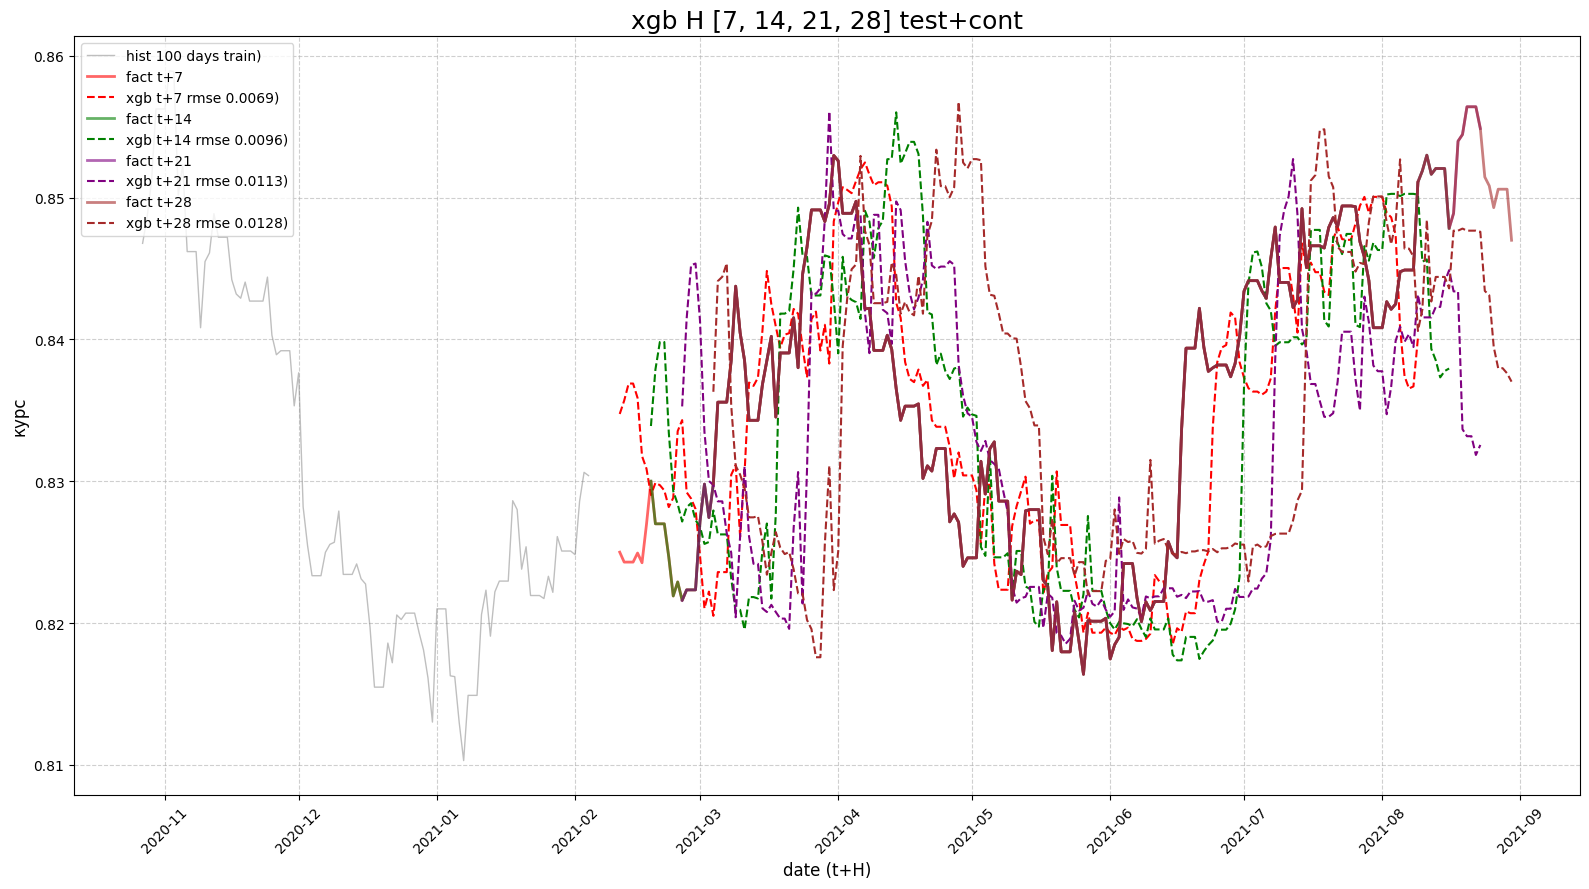

In [46]:
context_days = 100 

plt.figure(figsize=(16, 9))

test_start_date = test_index[0] 
context_start_date = test_start_date - pd.Timedelta(days=context_days)

historical_data_context = df_features[TARGET_COLUMN].loc[context_start_date:test_start_date]

plt.plot(historical_data_context.index, historical_data_context.values, 
         label=f'hist {context_days} days train)', color='gray', linewidth=1, alpha=0.5)

MAX_H = HORIZONS[-1] 

for H in HORIZONS:
    predicted_dates = test_index + pd.Timedelta(days=H)
    y_test_H = results[H]['y_test']
    pred = predictions[H]
    rmse = results[H]['rmse']
    
    
    plt.plot(predicted_dates, y_test_H, 
             label=f'fact t+{H}', 
             color=colors[H], 
             linestyle='-', 
             linewidth=2, 
             alpha=0.6)
    
    plt.plot(predicted_dates, pred, 
             label=f'xgb t+{H} rmse {rmse:.4f})', 
             color=colors[H], 
             linestyle='--', 
             alpha=1.0)

plt.title(f'xgb H {HORIZONS} test+cont', fontsize=18)
plt.xlabel('date (t+H)', fontsize=12)
plt.ylabel('курс', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
# выглядит ужасно
# мне показалось хорошей идеей скинуть все графики в кучу
# не читаемо

In [42]:
def calculate_directional_accuracy(y_true, y_pred):
    true_change = np.sign(y_true[1:] - y_true[:-1])
    pred_change = np.sign(y_pred[1:] - y_pred[:-1])
    
    correct_predictions = np.sum(true_change == pred_change)
    total_predictions = len(true_change)
    
    return (correct_predictions / total_predictions) * 100

da_results = {}
for H in HORIZONS:
    y_test = results[H]['y_test'].values
    pred = predictions[H]
    da_results[H] = calculate_directional_accuracy(y_test, pred)
    print(f"DA для H={H} дней: {da_results[H]:.2f}%")

DA для H=7 дней: 45.25%
DA для H=14 дней: 46.93%
DA для H=21 дней: 41.90%
DA для H=28 дней: 50.28%


In [44]:
performance_data = []
for H in HORIZONS:
    performance_data.append({
        'Горизонт (H)': H,
        'RMSE (Ошибка магн.)': results[H]['rmse'],
        'DA (Точность напр.)': da_results[H]
    })

performance_df = pd.DataFrame(performance_data).set_index('Горизонт (H)')
print(performance_df.to_markdown(floatfmt=".4f"))

|   Горизонт (H) |   RMSE (Ошибка магн.) |   DA (Точность напр.) |
|---------------:|----------------------:|----------------------:|
|              7 |                0.0069 |               45.2514 |
|             14 |                0.0096 |               46.9274 |
|             21 |                0.0113 |               41.8994 |
|             28 |                0.0128 |               50.2793 |


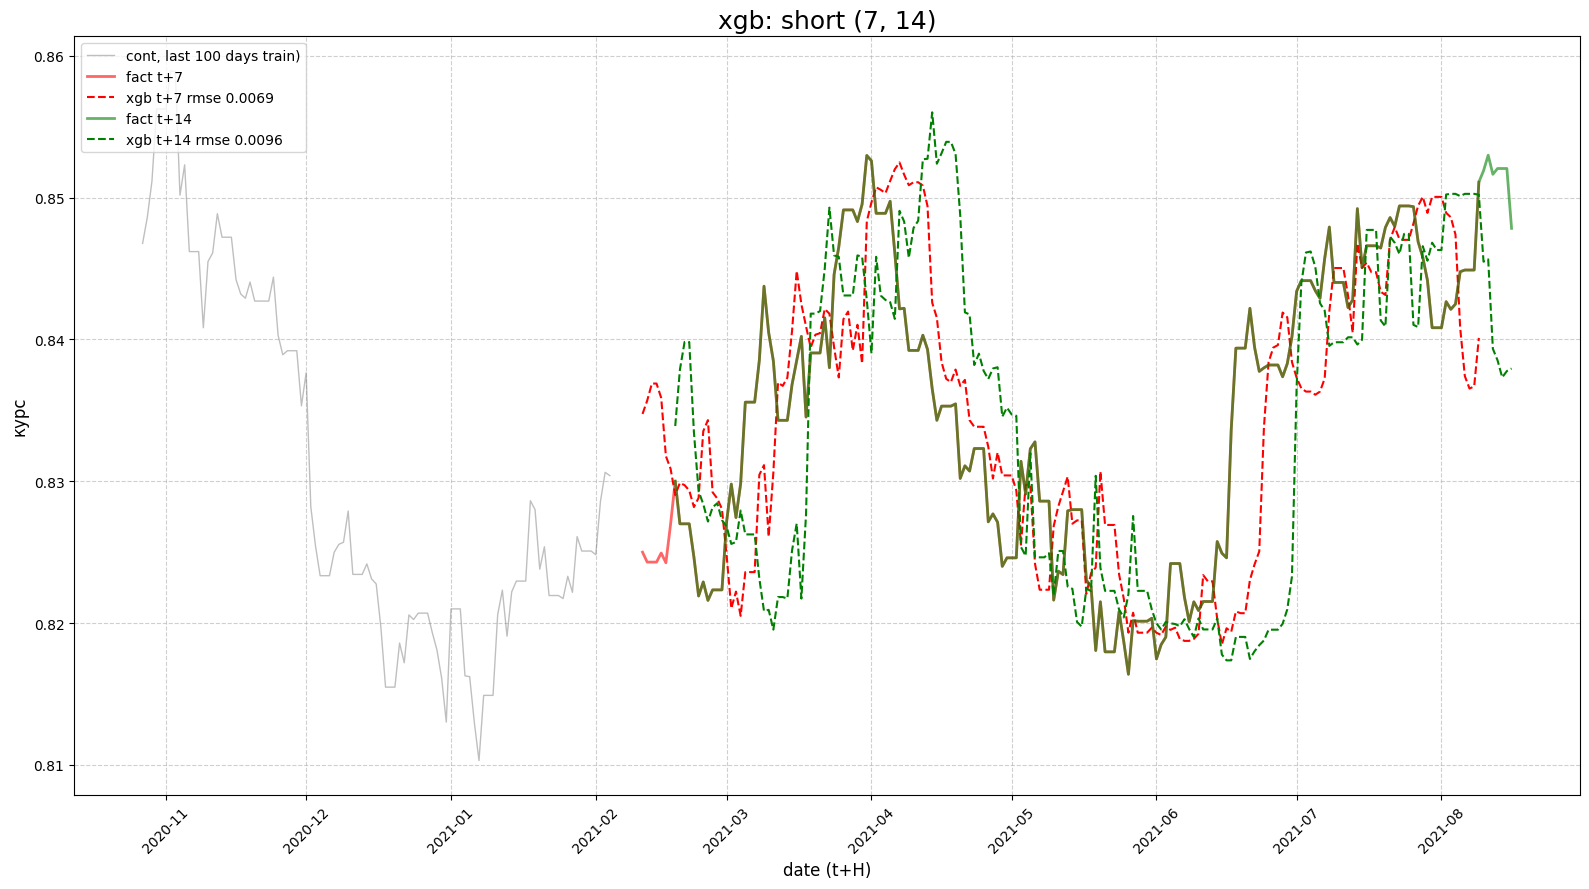

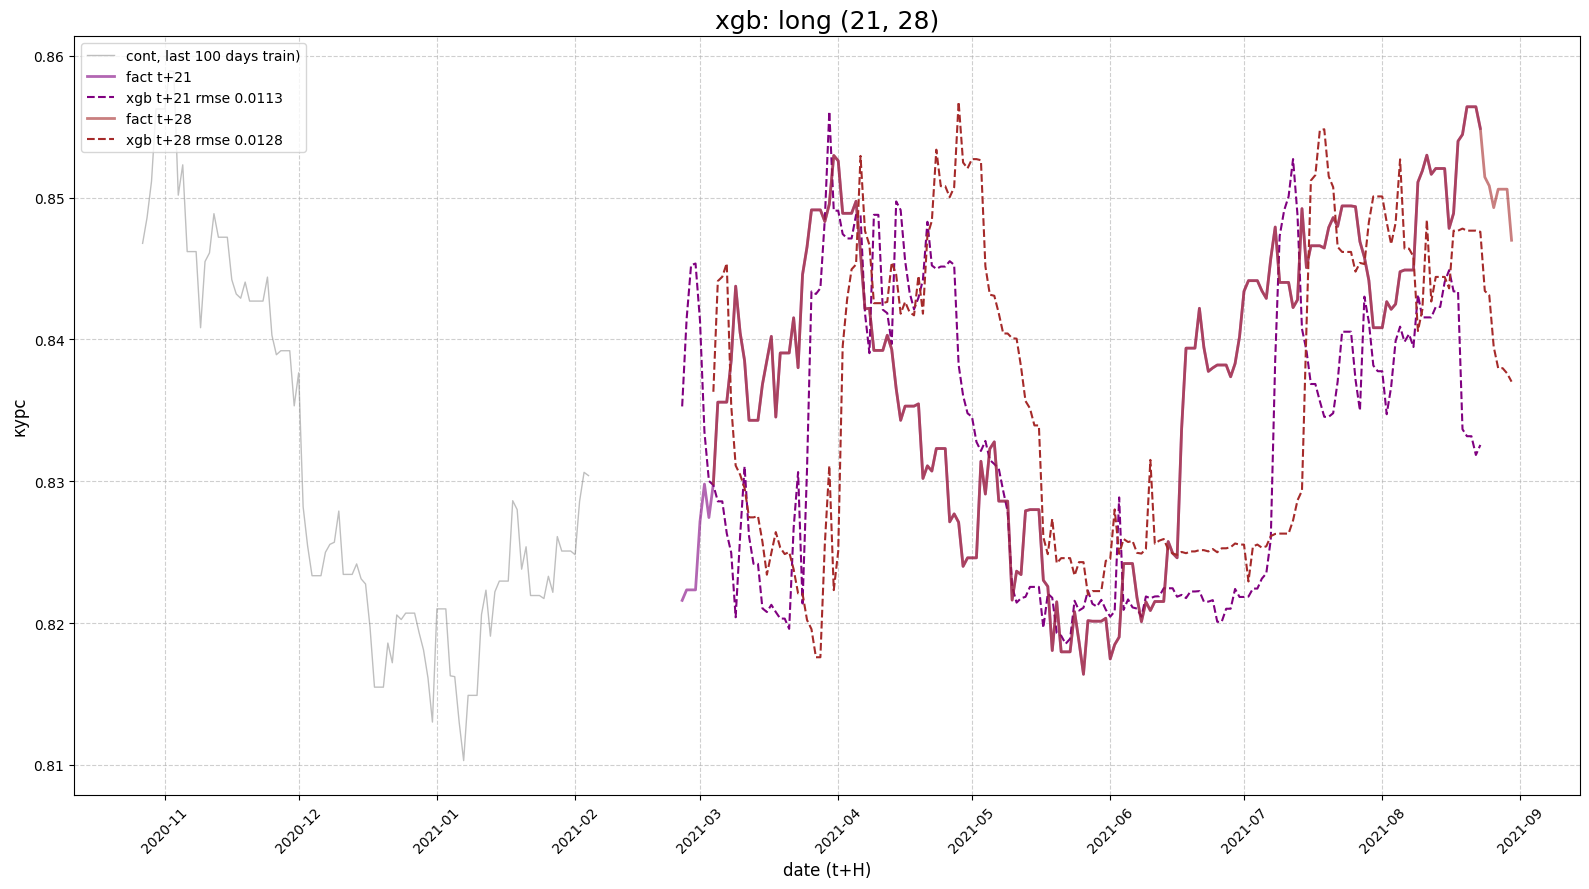

In [47]:
context_days = 100 
test_start_date = test_index[0] 
context_start_date = test_start_date - pd.Timedelta(days=context_days)
historical_data_context = df_features[TARGET_COLUMN].loc[context_start_date:test_start_date]
colors = {7: 'red', 14: 'green', 21: 'purple', 28: 'brown'}


def plot_horizons(plot_horizons, title_suffix):
    plt.figure(figsize=(16, 9))
    
    plt.plot(historical_data_context.index, historical_data_context.values, 
             label=f'cont, last {context_days} days train)', 
             color='gray', linewidth=1, alpha=0.5)

    for H in plot_horizons:
        predicted_dates = test_index + pd.Timedelta(days=H)
        y_test_H = results[H]['y_test']
        pred = predictions[H]
        rmse = results[H]['rmse']
        
        plt.plot(predicted_dates, y_test_H, 
                 label=f'fact t+{H}', 
                 color=colors[H], 
                 linestyle='-', 
                 linewidth=2, 
                 alpha=0.6)
        
        plt.plot(predicted_dates, pred, 
                 label=f'xgb t+{H} rmse {rmse:.4f}', 
                 color=colors[H], 
                 linestyle='--', 
                 alpha=1.0)

    plt.title(f'xgb: {title_suffix}', fontsize=18)
    plt.xlabel('date (t+H)', fontsize=12)
    plt.ylabel('курс', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper left', fontsize=10)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_horizons([7, 14], 'short (7, 14)')
plot_horizons([21, 28], 'long (21, 28)')

In [48]:
# выглядит ужасно х 2
# но лучше чем было
# но так все равно не пойдет

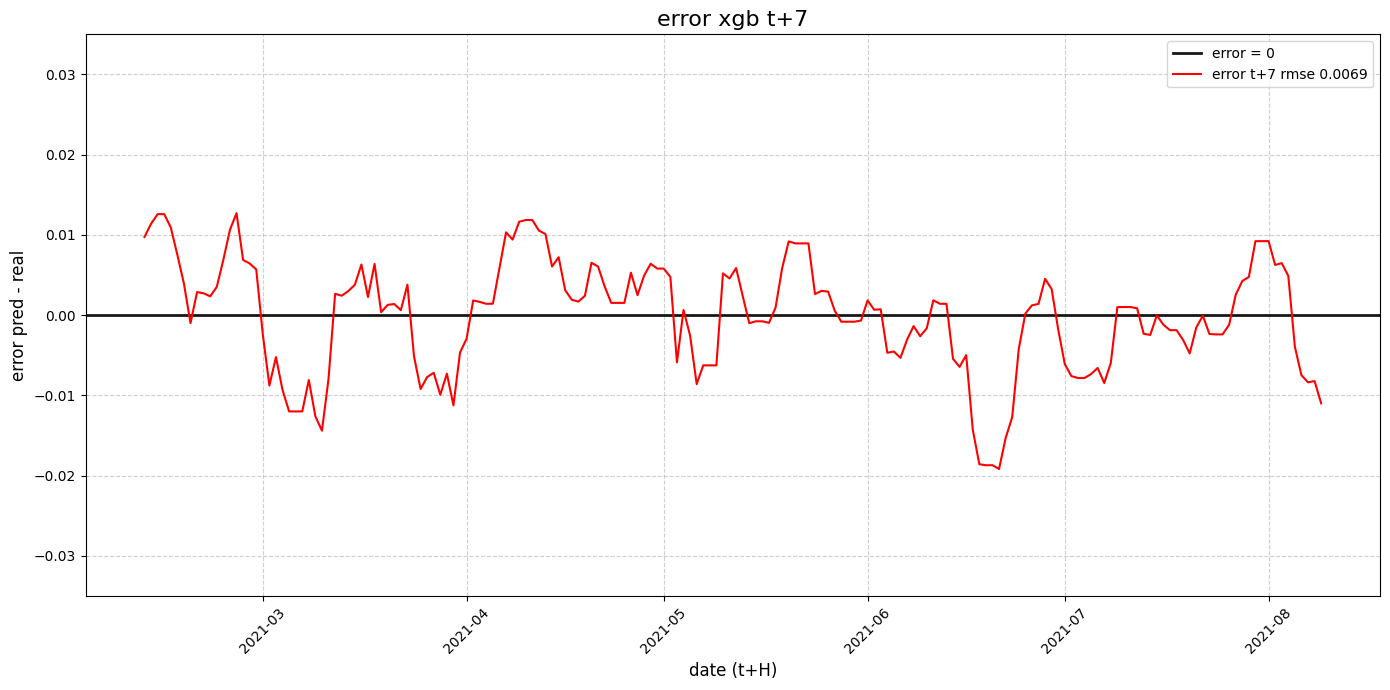

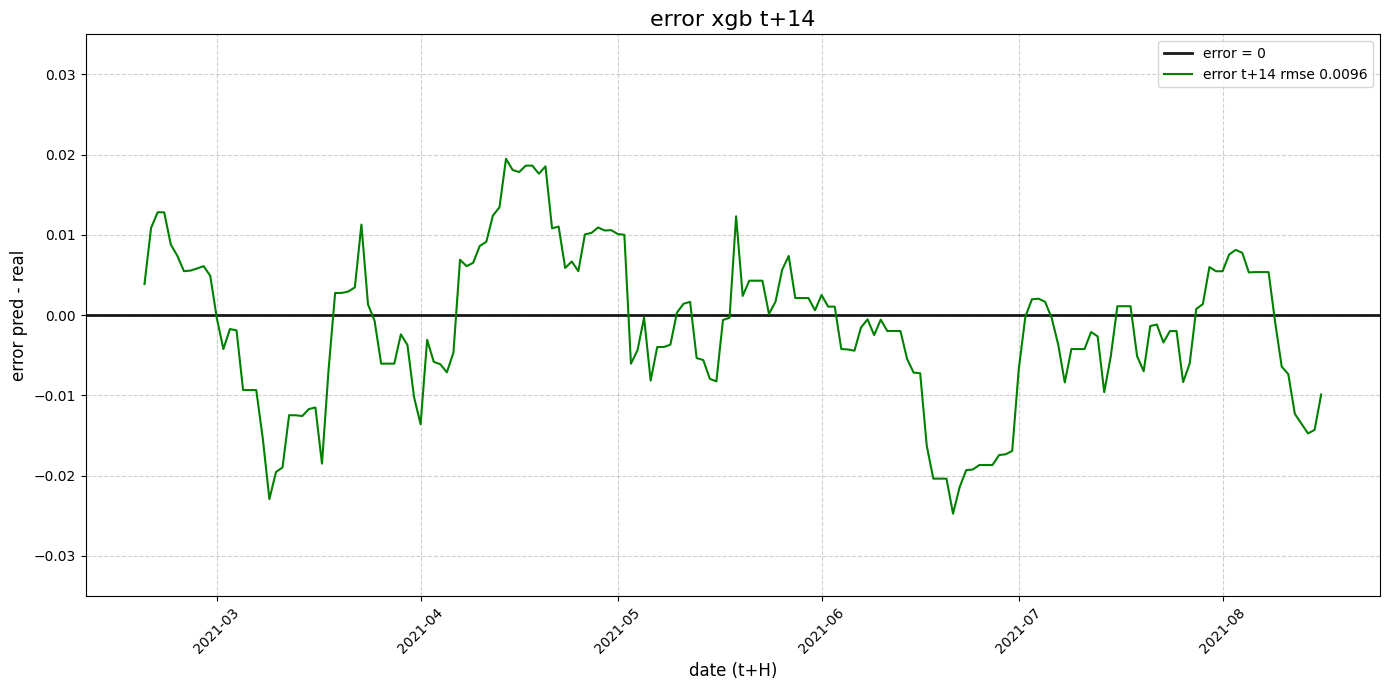

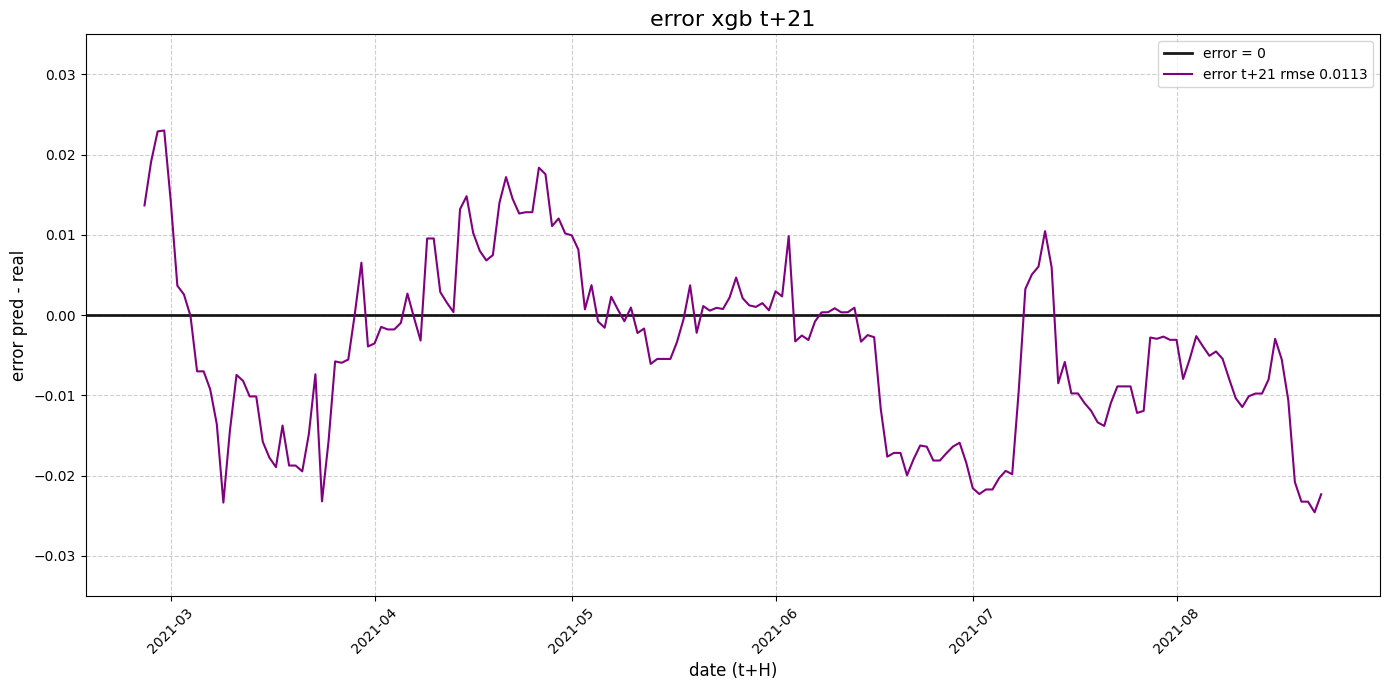

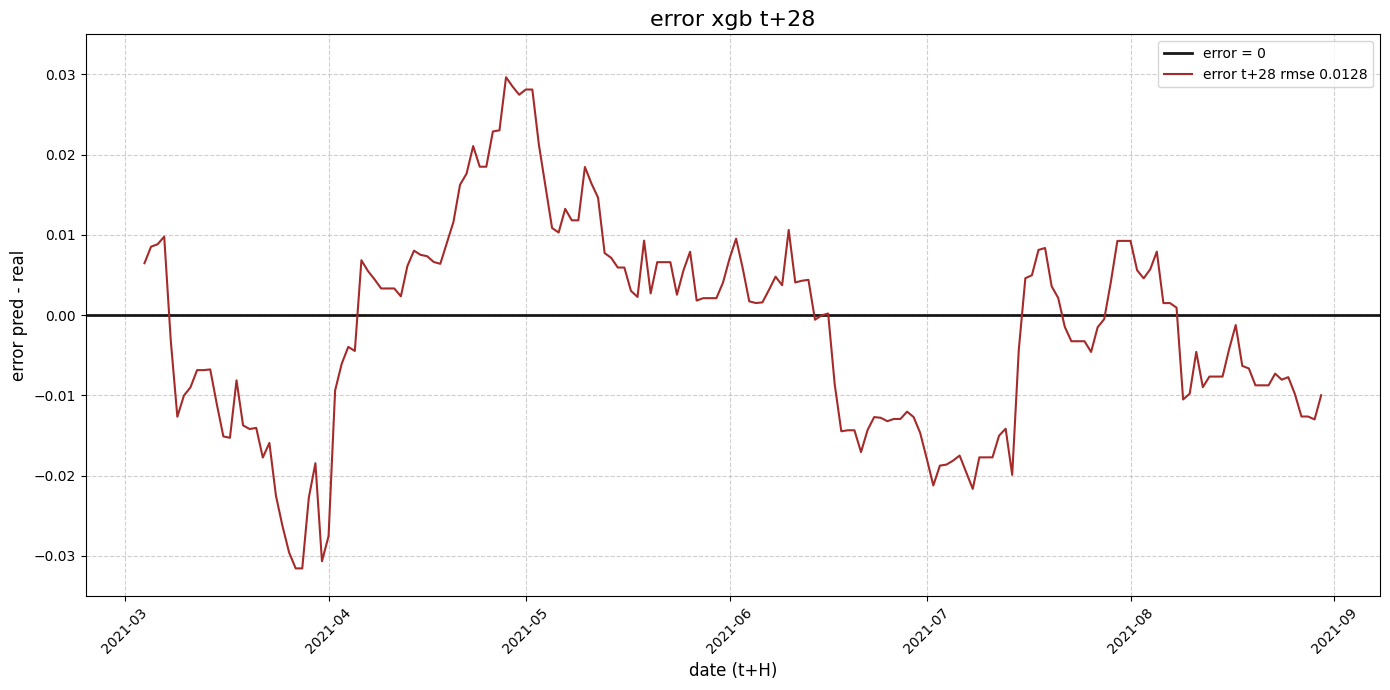

In [50]:
colors = {7: 'red', 14: 'green', 21: 'purple', 28: 'brown'}

def plot_single_error(H):
    
    y_test_H = results[H]['y_test']
    pred = predictions[H]
    rmse = results[H]['rmse']
    
    error = pred - y_test_H
    
    predicted_dates = test_index + pd.Timedelta(days=H)
    
    plt.figure(figsize=(14, 7))

    plt.axhline(0, color='black', linestyle='-', linewidth=2, alpha=0.9, label='error = 0')

    plt.plot(predicted_dates, error, 
             label=f'error t+{H} rmse {rmse:.4f}', 
             color=colors[H], 
             linestyle='-', 
             linewidth=1.5)

    plt.title(f'error xgb t+{H}', fontsize=16)
    plt.xlabel('date (t+H)', fontsize=12)
    plt.ylabel('error pred - real', fontsize=12)
    
    plt.ylim(-0.035, 0.035) 
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper right', fontsize=10)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

for H in HORIZONS:
    plot_single_error(H)

In [53]:
# ну эт еще +- сносно, график сделал от нуля, в каких местах расхождение с реальностью самое большое
# уже на 7 дней предикты такие, что можно весь портфель проторговать